<a href="https://colab.research.google.com/drive/1efQc2RsqbPMyykmM4D5m3dr0S4jZ9oDX?usp=sharing">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 🔬 Practical 8: Transfer Learning with VGG16 / ResNet50
## Deep Learning Lab | BTech Semester 4

---

### 🎯 Objective
Use pre-trained State-of-the-Art models to classify medical X-ray images — a real-world industry-standard practice.

**Key Concept: Transfer Learning** — Instead of training a deep CNN from scratch (which requires millions of images and days of training), we reuse a model already trained on ImageNet (1.2M images, 1000 classes) and adapt it to our task.

### 📌 What You Will Learn
- What Transfer Learning is and why it works
- How to load and use pre-trained models (VGG16, ResNet50)
- Freezing vs fine-tuning layers
- Building a custom classification head on top of a pre-trained backbone
- Comparing: Training from Scratch vs Transfer Learning

### 📚 References
- Simonyan & Zisserman (2014) — *VGGNet* https://arxiv.org/abs/1409.1556
- He et al. (2015) — *ResNet* https://arxiv.org/abs/1512.03385
- Raghu et al. (2019) — *Transfusion: Understanding Transfer Learning for Medical Imaging*
- Chest X-Ray Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
- Keras Transfer Learning Guide: https://keras.io/guides/transfer_learning/

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print('Libraries ready!')

TensorFlow: 2.20.0
Libraries ready!


## 💡 Step 2: Transfer Learning — Theory & Intuition

CNNs trained on ImageNet learn a hierarchy of visual features:
- **Early layers**: edges, corners, blobs (universal, reusable)
- **Middle layers**: textures, shapes (semi-universal)
- **Late layers**: semantic concepts specific to ImageNet classes

We keep the feature extractor (frozen) and replace only the final classifier.

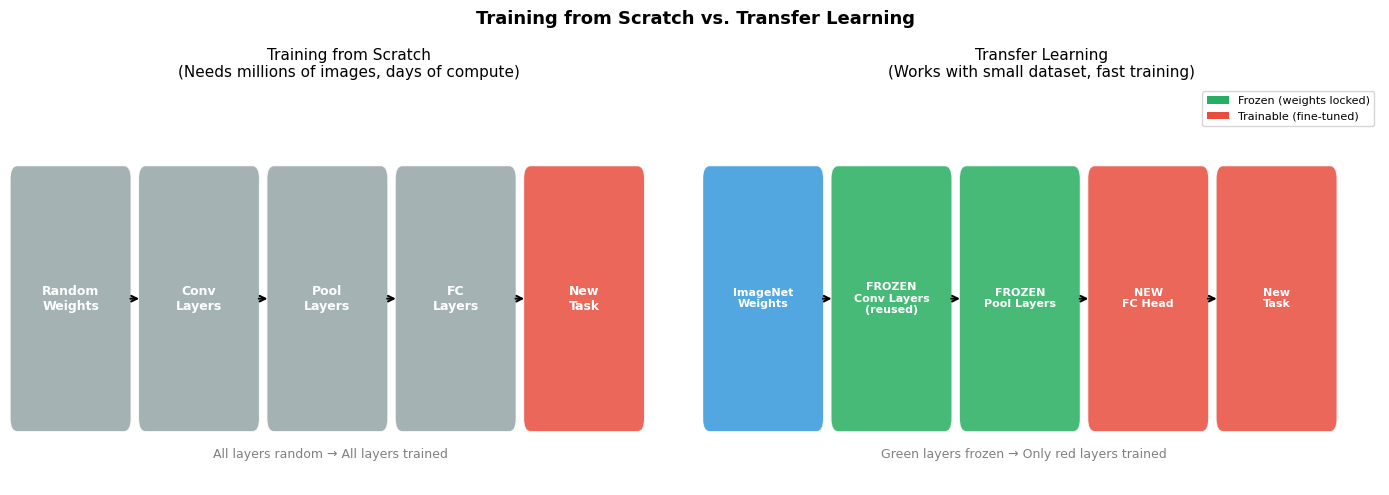

In [2]:
# drawing a diagram to visualize how transfer learning differs from training from scratch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left side of the diagram — training from scratch
stages_scratch = ['Random\nWeights', 'Conv\nLayers', 'Pool\nLayers', 'FC\nLayers', 'New\nTask']
colors_scratch  = ['#95A5A6'] * 5
colors_scratch[-1] = '#E74C3C'

for i, (s, c) in enumerate(zip(stages_scratch, colors_scratch)):
    rect = mpatches.FancyBboxPatch((i*1.8+0.1, 0.5), 1.5, 1.8,
                                    boxstyle='round,pad=0.1', facecolor=c, alpha=0.85, edgecolor='white')
    axes[0].add_patch(rect)
    axes[0].text(i*1.8+0.85, 1.4, s, ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if i < len(stages_scratch)-1:
        axes[0].annotate('', xy=((i+1)*1.8+0.05, 1.4), xytext=(i*1.8+1.65, 1.4),
                         arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
axes[0].set_xlim(0, 9.5); axes[0].set_ylim(0, 3); axes[0].axis('off')
axes[0].set_title('Training from Scratch\n(Needs millions of images, days of compute)', fontsize=11)
axes[0].text(4.5, 0.2, 'All layers random → All layers trained', ha='center', fontsize=9, color='gray')

# right side — using transfer learning
stages_tl = ['ImageNet\nWeights', 'FROZEN\nConv Layers\n(reused)', 'FROZEN\nPool Layers', 'NEW\nFC Head', 'New\nTask']
colors_tl  = ['#3498DB', '#27AE60', '#27AE60', '#E74C3C', '#E74C3C']

for i, (s, c) in enumerate(zip(stages_tl, colors_tl)):
    rect = mpatches.FancyBboxPatch((i*1.8+0.1, 0.5), 1.5, 1.8,
                                    boxstyle='round,pad=0.1', facecolor=c, alpha=0.85, edgecolor='white')
    axes[1].add_patch(rect)
    axes[1].text(i*1.8+0.85, 1.4, s, ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if i < len(stages_tl)-1:
        axes[1].annotate('', xy=((i+1)*1.8+0.05, 1.4), xytext=(i*1.8+1.65, 1.4),
                         arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
axes[1].set_xlim(0, 9.5); axes[1].set_ylim(0, 3); axes[1].axis('off')
axes[1].set_title('Transfer Learning\n(Works with small dataset, fast training)', fontsize=11)
legend_els = [mpatches.Patch(facecolor='#27AE60', label='Frozen (weights locked)'),
               mpatches.Patch(facecolor='#E74C3C', label='Trainable (fine-tuned)')]
axes[1].legend(handles=legend_els, loc='upper right', fontsize=8)
axes[1].text(4.5, 0.2, 'Green layers frozen → Only red layers trained', ha='center', fontsize=9, color='gray')

plt.suptitle('Training from Scratch vs. Transfer Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📂 Step 3: Load the Chest X-Ray Dataset

**Option A:** Download from Kaggle (requires API key)
**Option B:** Use CIFAR-10 as a proxy dataset (runs immediately, no download needed)

In [ ]:
# =====================================================================
# OPTION A: real chest x-ray dataset from Kaggle
# uncomment this block if you have your Kaggle API key ready
# =====================================================================
# from google.colab import files
# files.upload()  # Upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
# !unzip chest-xray-pneumonia.zip -d chest_xray
# TRAIN_DIR = 'chest_xray/chest_xray/train'
# VAL_DIR   = 'chest_xray/chest_xray/val'
# TEST_DIR  = 'chest_xray/chest_xray/test'
# USE_XRAY = True

# =====================================================================
# OPTION B: using CIFAR-10 cats vs dogs as a stand-in dataset
# no downloads needed — runs immediately
# class 3 (cat) → label 0, class 5 (dog) → label 1
# =====================================================================
USE_XRAY = False  # Set to True if using real X-ray dataset above

(X_raw, y_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# filtering out only cats and dogs from CIFAR-10 and relabeling them as 0 and 1
def filter_binary(X, y, class_a=3, class_b=5):
    mask = (y.flatten() == class_a) | (y.flatten() == class_b)
    X_f = X[mask]
    y_f = (y[mask].flatten() == class_b).astype(int)  # 0=cat, 1=dog
    return X_f, y_f

X_train_raw, y_train = filter_binary(X_raw, y_raw)
X_test_data, y_test  = filter_binary(X_test_raw, y_test_raw)

# normalizing pixel values to [0,1]
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test_data = X_test_data.astype('float32')  / 255.0

# resizing to 224x224 because VGG16 and ResNet50 were designed for this input size
IMG_SIZE = 224
X_train_resized = tf.image.resize(X_train_raw, [IMG_SIZE, IMG_SIZE]).numpy()
X_test_resized  = tf.image.resize(X_test_data,  [IMG_SIZE, IMG_SIZE]).numpy()

CLASS_NAMES = ['Normal (Cat proxy)', 'Pneumonia (Dog proxy)']
print(f'Training: {X_train_resized.shape}')
print(f'Test:     {X_test_resized.shape}')
print(f'Class distribution — Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}')
print(f'\nusing CIFAR-10 cats/dogs as a proxy dataset. set USE_XRAY=True to use the real chest x-ray data.')

## 🔍 Step 4: Explore the Data

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idxs = np.where(y_train == cls_idx)[0][:5]
    for j, idx in enumerate(idxs):
        axes[cls_idx, j].imshow(X_train_raw[idx])
        axes[cls_idx, j].set_title(f'{cls_name}', fontsize=8)
        axes[cls_idx, j].axis('off')

plt.suptitle('Sample Images by Class', fontsize=13)
plt.tight_layout()
plt.show()

# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = np.bincount(y_train)
ax.bar(CLASS_NAMES, counts, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution — Training Set')
ax.set_ylabel('Count')
for i, c in enumerate(counts):
    ax.text(i, c + 20, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 🏗️ Step 5: Build Models — Three Approaches

We compare three strategies:
1. **From Scratch** — baseline CNN trained only on our small dataset
2. **VGG16 Feature Extraction** — VGG16 backbone frozen, only new head trained
3. **VGG16 Fine-Tuning** — VGG16 partially unfrozen, top layers fine-tuned

In [ ]:
# -----------------------------------------------------------------------
# Model 1: Simple CNN from scratch (baseline)
# -----------------------------------------------------------------------
def build_from_scratch(input_shape=(224, 224, 3)):
    """a simple CNN trained only on our data from scratch
    this is the baseline — no pre-training, so it has to learn everything from our small dataset"""
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # single output neuron with sigmoid — gives probability between 0 and 1
    ], name='FromScratch')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


# -----------------------------------------------------------------------
# Model 2: VGG16 Feature Extraction — ALL backbone layers FROZEN
# -----------------------------------------------------------------------
def build_vgg16_feature_extraction(input_shape=(224, 224, 3)):
    """
    loading VGG16 with ImageNet weights
    include_top=False removes the original 1000-class head — we'll add our own
    all VGG16 layers are frozen so they don't update — it just extracts features for us
    """
    # loading VGG16 with pretrained weights — will auto-download if not cached
    base_model = VGG16(
        weights='imagenet',     # Use ImageNet pre-trained weights
        include_top=False,      # Remove original 1000-class head
        input_shape=input_shape
    )

    # FREEZE all base model layers — no weight updates
    base_model.trainable = False  # locking all VGG16 layers — no weight updates during training

    # adding our own new classification layers on top of the frozen VGG16 backbone
    inputs  = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)  # training=False keeps BatchNorm in eval mode (important for frozen layers)
    x = layers.GlobalAveragePooling2D()(x)  # averaging over the spatial dimensions to get a flat feature vector
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  # final binary prediction (0=normal, 1=pneumonia)

    model = keras.Model(inputs, outputs, name='VGG16_FeatureExtraction')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    print(f'VGG16 trainable layers: {sum(1 for l in model.layers if l.trainable)}  (only our new head is training)')
    print(f'VGG16 frozen layers: {sum(1 for l in model.layers if not l.trainable)}  (all backbone weights are locked)')
    return model, base_model


# -----------------------------------------------------------------------
# Model 3: VGG16 Fine-Tuning — UNFREEZE top conv block
# -----------------------------------------------------------------------
def build_vgg16_finetuned(base_model, input_shape=(224, 224, 3)):
    """
    fine-tuning: we unfreeze the last conv block (block5) of VGG16
    the early layers detect generic features (edges, textures) so we keep them frozen
    block5 detects high-level patterns — we let it adapt to our specific task
    VERY IMPORTANT: use tiny learning rate (1e-5) or we'll destroy the pre-trained weights
    """
    # first unlocking everything, then we'll re-freeze the early layers selectively
    base_model.trainable = True

    # keeping early layers frozen, only allowing block5 to be fine-tuned
    for layer in base_model.layers:
        if 'block5' not in layer.name:
            layer.trainable = False  # these layers detect general features — no need to change them
        else:
            layer.trainable = True   # block5 detects high-level patterns — we adapt these to our task

    # Count trainable layers
    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f'Fine-tuning: {trainable} layers unfrozen in VGG16 block5')

    inputs  = keras.Input(shape=input_shape)
    x = base_model(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='VGG16_FineTuned')
    # using a tiny learning rate — fine-tuning with a large LR would destroy the pre-trained weights (catastrophic forgetting)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


print('Model builder functions defined!')

## 🚀 Step 6: Train All Three Models

In [ ]:
# using 2000 samples to keep training fast — you can increase this for better results
N_TRAIN = 2000
Xtr = X_train_resized[:N_TRAIN]
ytr = y_train[:N_TRAIN]

EPOCHS    = 15
BATCH     = 32
VAL_SPLIT = 0.2
results   = {}

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

# --- Model 1: From Scratch ---
print('\n' + '='*50)
print('Training Model 1: From Scratch')
print('='*50)
m1 = build_from_scratch()
h1 = m1.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH,
             validation_split=VAL_SPLIT, callbacks=[early_stop], verbose=1)
t1_loss, t1_acc = m1.evaluate(X_test_resized, y_test, verbose=0)
results['From Scratch']  = {'history': h1, 'test_acc': t1_acc, 'color': 'red'}
print(f'Test Acc: {t1_acc*100:.2f}%')

# --- Model 2: VGG16 Feature Extraction ---
print('\n' + '='*50)
print('Training Model 2: VGG16 Feature Extraction (Frozen)')
print('='*50)
m2, base = build_vgg16_feature_extraction()
h2 = m2.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH,
             validation_split=VAL_SPLIT, callbacks=[early_stop], verbose=1)
t2_loss, t2_acc = m2.evaluate(X_test_resized, y_test, verbose=0)
results['VGG16 Feature Extraction'] = {'history': h2, 'test_acc': t2_acc, 'color': 'blue'}
print(f'Test Acc: {t2_acc*100:.2f}%')

# --- Model 3: VGG16 Fine-Tuned ---
print('\n' + '='*50)
print('Training Model 3: VGG16 Fine-Tuning (block5 unfrozen)')
print('='*50)
m3 = build_vgg16_finetuned(base)
h3 = m3.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH,
             validation_split=VAL_SPLIT, callbacks=[early_stop], verbose=1)
t3_loss, t3_acc = m3.evaluate(X_test_resized, y_test, verbose=0)
results['VGG16 Fine-Tuned'] = {'history': h3, 'test_acc': t3_acc, 'color': 'green'}
print(f'Test Acc: {t3_acc*100:.2f}%')

print('\nall 3 models trained and ready to compare!')

## 📊 Step 7: Compare Convergence Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    h = res['history'].history
    ep = range(1, len(h['loss'])+1)
    axes[0].plot(ep, h['val_loss'],     color=res['color'], linewidth=2, label=name)
    axes[1].plot(ep, h['val_accuracy'], color=res['color'], linewidth=2, label=name)

axes[0].set_title('Validation Loss vs. Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy vs. Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('From Scratch vs. Transfer Learning Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 Step 8: Summary Table & Evaluation

In [ ]:
rows = []
for name, res in results.items():
    h = res['history'].history
    rows.append({
        'Model': name,
        'Epochs Run': len(h['loss']),
        'Best Val Acc': f"{max(h['val_accuracy'])*100:.2f}%",
        'Test Accuracy': f"{res['test_acc']*100:.2f}%",
        'Convergence Speed': 'Slow' if name == 'From Scratch' else 'Fast'
    })

df = pd.DataFrame(rows)
print('Model Comparison:')
print(df.to_string(index=False))

print('\nKey Observations:')
print('  transfer learning hits higher accuracy in fewer epochs')
print('  feature extraction is great when your dataset is small')
print('  fine-tuning tweaks the high-level features to fit your specific task better')
print('  training from scratch needs way more data and time to match transfer learning')

## 🔍 Step 9: Visualize VGG16 Architecture

In [ ]:
# printing out VGG16's layer structure block by block
vgg_temp = VGG16(weights=None, include_top=False, input_shape=(224, 224, 3))

print('VGG16 Architecture (feature extractor, no top):')
print('-' * 55)
current_block = ''
for layer in vgg_temp.layers:
    if hasattr(layer, 'kernel'):
        block = layer.name.split('_')[0]
        if block != current_block:
            print(f'  [{block.upper()}]')
            current_block = block
    out_shape = layer.output.shape
    print(f'    {layer.name:<25} Output: {str(out_shape[1:]):>15}')
print('-' * 55)
print(f'Total VGG16 parameters: {vgg_temp.count_params():,}')

## 🔎 Step 10: Confusion Matrix for Best Model

In [ ]:
# evaluating our best model (fine-tuned VGG16) on the held-out test set
best_model = m3
y_pred_prob = best_model.predict(X_test_resized, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — VGG16 Fine-Tuned')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\nClassification Report — VGG16 Fine-Tuned:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

---

## 📝 Summary

| Strategy | Frozen Layers | Trainable | LR | Best For |
|----------|--------------|-----------|-----|----------|
| From Scratch | None | All | Normal | Large datasets |
| Feature Extraction | All backbone | Head only | 1e-4 | Very small datasets |
| Fine-Tuning | Early layers | Last block + head | 1e-5 | Moderate dataset, different domain |

**When to use Transfer Learning:**
- Your dataset is small (< 10,000 images)
- Your task is visually similar to ImageNet
- You have limited compute resources

---

## ❓ Viva / Self-Check Questions

1. **What is Transfer Learning?** Why does it work — what assumption does it rely on about learned features?

2. **What does `include_top=False` mean when loading VGG16?** What happens to the original classification head?

3. **What does 'freezing' a layer mean?** What happens to its gradients during backpropagation?

4. **Why must we use a very small learning rate (1e-5) during fine-tuning?** What is 'catastrophic forgetting'?

5. **What is `GlobalAveragePooling2D`?** How does it reduce a feature map (H×W×C) to a vector?

6. **VGG16 has 138 million parameters. Why does training our custom head still work despite the backbone being frozen?**

7. **What is the difference between Feature Extraction and Fine-Tuning?** When would you choose one over the other?

8. **What is ResNet's key innovation?** What problem did it solve that made training 50+ layer networks possible?